In [4]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
# Step 1 : Load Dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target
print("Dataset Shape :", X.shape)



Dataset Shape : (20640, 8)


In [6]:
# Step 2 : Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:
# Step 3 : Train Baseline Model
baseline_model = DecisionTreeRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
# Step 4 : Cross Validation
cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
print("\nCross Validation Scores")
print(cv_scores)
print("\nAverage CV Score :", cv_scores.mean())


Cross Validation Scores
[0.58536943 0.58438558 0.6343082  0.59297484 0.63909754]

Average CV Score : 0.6072271176364323


In [9]:
# Step 5 : Check Overfitting
train_score = baseline_model.score(X_train, y_train)
test_score = baseline_model.score(X_test, y_test)
print("\nTraining R2 :", train_score)
print("Testing R2  :", test_score)


Training R2 : 1.0
Testing R2  : 0.622075845135081


In [10]:
# Step 6 : Hyperparameter Tuning
parameters = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("\nBest Parameters")
print(grid_search.best_params_)
print("\nBest Cross Validation Score")
print(grid_search.best_score_)


Best Parameters
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score
0.7100830403599112


In [11]:
# Step 7 : Train Best Model
best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

In [12]:
# Step 8 : Evaluation
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print("\nFinal Model Performance")
print("RMSE :", round(rmse, 4))
print("R2 Score :", round(r2, 4))


Final Model Performance
RMSE : 0.6391
R2 Score : 0.6883


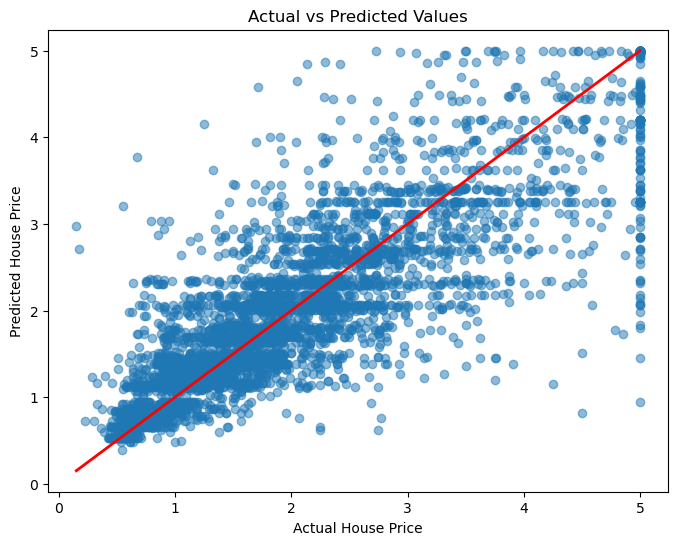

In [13]:
# Step 9 : Actual vs Predicted Graph
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted Values")
plt.show()

In [14]:
# Step 10 : Comparison
baseline_prediction = baseline_model.predict(X_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))
baseline_r2 = r2_score(y_test, baseline_prediction)
print("\n-------------------------------")
print("Baseline Model")
print("-------------------------------")
print("RMSE :", round(baseline_rmse,4))
print("R2   :", round(baseline_r2,4))
print("\n-------------------------------")
print("Tuned Model")
print("-------------------------------")
print("RMSE :", round(rmse,4))
print("R2   :", round(r2,4))


-------------------------------
Baseline Model
-------------------------------
RMSE : 0.7037
R2   : 0.6221

-------------------------------
Tuned Model
-------------------------------
RMSE : 0.6391
R2   : 0.6883
